# RHIC comparison: in-jet heavy-quark EECs

This notebook computes the **same conditional EEC** as the LHC notebook, now for p–Au at
$\sqrt{s_{NN}}=200$ GeV. The main scan uses $y_J=2$, $p_T=5,7.5,10$ GeV,
$m_Q=1.3$ GeV, $R_J=0.6$, $A=197$, and $c=0.75$.
Both GBW and MV use $Q_s^2=Q_{s,0}^2(x_0/x_t)^{0.29}$ and
$Q_{s,A}^2=cA^{1/3}Q_{s,p}^2$, exactly as in the original notebook.

**The calculation retains the previous leading-power approximations.** In particular,
$x_{p,t}=p_Te^{\pm y_J}/\sqrt{s_{NN}}$, $k=z(1-z)p_TR_L$, and the energy weight is $z(1-z)$.
It is an internally consistent comparison within that formula, not an exact massive-kinematics
prediction. At 5 GeV, $M_J^2/p_T^2\ge4m_Q^2/p_T^2=0.2704$; that bin is exploratory.
The mass is retained in the splitting kernel. No PDF/area/coupling prefactor or extra $1/A$
is inserted into the conditional ratio $R_{pA}^{\rm EEC}=C_A/C_p$.

The new notation in **In_jet_EECs-11.pdf**, with $R_{12}$ in the denominator kernel,
corresponds to
$$C_X(R)=\frac{\Theta(R_J-R)R\int dz\,b^3\mathcal I_X(p_T,bp_TR;z)}
{\int_0^{R_J}dR'\,R'\int dz\,b^2\mathcal I_X(p_T,bp_TR';z)},\qquad b=z(1-z),$$
where $\mathcal I_X$ includes the azimuthal integral. Its integral over $R$ is $\langle b\rangle$,
not one. We also retain the deterministic product of dipoles and use no BK evolution.

**Run All** reproduces the plots and exports tables to `rhic_results/`.
The notebook contains the full solver, so it can be copied and run independently.
Dependencies: NumPy, SciPy, pandas, Matplotlib and Jupyter.

In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
from IPython.display import display
from dataclasses import dataclass, replace, asdict
from functools import lru_cache
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
from scipy.fft import fht, fhtoffset
from scipy.integrate import quad, simpson
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq
from scipy.special import j0, ndtri
from scipy.stats import qmc


@dataclass(frozen=True)
class Physics:
    sqrt_s: float = 200.0       # nucleon-nucleon CM energy [GeV]
    y_J: float = 2.0             # positive rapidity = proton-going direction
    p_T: float = 5.0            # infinitesimal jet bin [GeV]
    m_Q: float = 1.3             # charm mass [GeV], fixed phenomenological input
    R_J: float = 0.6
    A: float = 197.0             # Au
    c_nuclear: float = 0.75      # Eq. (43), vary over 0.5--1.0
    Qs0_sq: float = 1.0          # [GeV^2]
    x0: float = 3.04e-4
    lambda_s: float = 0.29
    Lambda_MV: float = 0.2       # [GeV]
    z_min: float = 0.0           # 0 reproduces the notes; same cut in both integrals

    def __post_init__(self):
        if not (self.sqrt_s > 0 and self.p_T > 0 and self.m_Q > 0):
            raise ValueError('sqrt_s, p_T and m_Q must be positive.')
        if not (0 < self.R_J <= 1 and 0 <= self.z_min < 0.5):
            raise ValueError('Use 0 < R_J <= 1 and 0 <= z_min < 0.5.')
        if min(self.A, self.c_nuclear, self.Qs0_sq, self.x0, self.Lambda_MV) <= 0:
            raise ValueError('Target and dipole parameters must be positive.')
        if not (0 < self.x_p < 1 and 0 < self.x_t < 1):
            raise ValueError('The selected kinematics give an unphysical momentum fraction.')

    @property
    def x_p(self):
        return self.p_T * np.exp(self.y_J) / self.sqrt_s

    @property
    def x_t(self):
        return self.p_T * np.exp(-self.y_J) / self.sqrt_s

    def Qs(self, target):
        if target not in ('p', 'A'):
            raise ValueError("target must be 'p' or 'A'")
        enhancement = 1.0 if target == 'p' else self.c_nuclear * self.A**(1/3)
        return np.sqrt(self.Qs0_sq * (self.x0/self.x_t)**self.lambda_s * enhancement)


@dataclass(frozen=True)
class Numerics:
    power: int = 18              # 2**power points in each independent Sobol scramble
    repeats: int = 8             # uncertainty from independent scrambles
    n_R: int = 48                # Gauss-Legendre nodes for the jet-rate denominator
    seed: int = 260922
    fft_n: int = 16384           # MV Hankel table

    def __post_init__(self):
        if self.power < 5 or self.repeats < 2 or self.n_R < 8 or self.fft_n < 1024:
            raise ValueError('Numerical settings are too small for this solver.')


PHYSICS = Physics()
NUMERICS = Numerics()
MODEL = 'MV'                    # 'GBW' or 'MV'
COMPARE_MODELS = True           # False runs only MODEL
RUN_PARAMETER_SCAN = True
RUN_CONVERGENCE = True
R_L = np.geomspace(0.008, PHYSICS.R_J, 65)
OUTPUT = Path('rhic_results')
OUTPUT.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 115, 'savefig.dpi': 180, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.2,
})
# These cases keep all internal cuts and the charm mass identical.
CASES = {
    'RHIC_5': PHYSICS,
    'RHIC_7p5': replace(PHYSICS, p_T=7.5),
    'RHIC_10': replace(PHYSICS, p_T=10.0),
    'LHC_5_matched': replace(PHYSICS, sqrt_s=5020.0),
    'LHC_10_matched': replace(PHYSICS, sqrt_s=5020.0, p_T=10.0),
    'LHC_25_original': replace(PHYSICS, sqrt_s=5020.0, p_T=25.0, y_J=3.0, A=208.0),
}
R_L = np.unique(np.r_[np.geomspace(.008, PHYSICS.R_J, 65), .1, .3, .6])
RUN_CONVERGENCE = True

## Dipoles and full combined kernel

GBW is sampled using its exact conditional Gaussian, so its common hard-$p_T$ exponential
never enters a numerical division. MV uses a numerical Hankel transform, with the same
coordinate-space logarithm and GBW estimate of $Q_s(x)$ as before.
Its Student-t importance sampler covers the full transverse plane.

For comparison with saturation angles we report $Q_{\rm op}$ defined by
$S(2/Q_{\rm op})=e^{-1}$. This is a diagnostic scale; it does not replace the input $Q_s$.

In [2]:
class GBWDipole:
    name = 'GBW'

    def __init__(self, Qs, Lambda=0.2, fft_n=16384):
        self.Qs = float(Qs)

    def S(self, r):
        r = np.asarray(r, dtype=float)
        return np.exp(-r*r*self.Qs**2/4)

    def F(self, q):
        q = np.asarray(q, dtype=float)
        return np.exp(-q*q/self.Qs**2)/(np.pi*self.Qs**2)

    def log_F(self, q):
        return -np.asarray(q)**2/self.Qs**2 - np.log(np.pi*self.Qs**2)

    @property
    def Q_operational(self):
        # Defined by S(2/Q_operational) = exp(-1).
        return self.Qs


class MVDipole:
    name = 'MV'

    def __init__(self, Qs, Lambda=0.2, fft_n=16384):
        self.Qs, self.Lambda = float(Qs), float(Lambda)
        Q = self.Qs
        r = np.geomspace(1e-9/Q, 1e3/Q, fft_n)
        dln = np.log(r[1]/r[0])
        bias = 0.5
        offset = fhtoffset(dln, mu=0, initial=0, bias=bias)
        q = np.exp(offset)/r[::-1]
        # Subtract a smooth Gaussian and transform it analytically. This reduces
        # cancellation/ringing without changing the coordinate-space MV model.
        a = Q**2/4 * np.log(np.e + Q/self.Lambda)
        residual = r*(self.S(r) - np.exp(-a*r*r))
        fq = (fht(residual, dln, mu=0, offset=offset, bias=bias)/(2*np.pi*q)
              + np.exp(-q*q/(4*a))/(4*np.pi*a))
        keep = (q >= 1e-3*Q) & (q <= 1e3*Q)
        self.q_grid, self.f_grid = q[keep], fq[keep]
        if np.any(~np.isfinite(self.f_grid)) or np.any(self.f_grid <= 0):
            raise ArithmeticError('MV transform lost positivity; refine the Hankel grid.')
        self.q_min, self.q_max = self.q_grid[[0, -1]]
        self._log_interp = PchipInterpolator(np.log(self.q_grid), np.log(self.f_grid))
        def moment(power):
            def integrand(t):
                if t == 0:
                    return 0.0
                return t**power*np.exp(-t*t/4*np.log(np.e+Q/(self.Lambda*t)))
            return quad(integrand, 0, 30, epsabs=1e-12, epsrel=2e-11)[0]
        self.F0 = moment(1)/(2*np.pi*Q**2)
        self.curvature = moment(3)/(8*np.pi*Q**4)
        self.tail_coefficient_ratio = self.f_grid[-1]*2*np.pi*self.q_max**4/Q**2

    def S(self, r):
        r = np.asarray(r, dtype=float)
        rr = np.maximum(r, np.finfo(float).tiny)
        logarithm = np.logaddexp(1.0, -np.log(rr)-np.log(self.Lambda))
        return np.exp(-r*r*self.Qs**2/4*logarithm)

    def F(self, q):
        q = np.abs(np.asarray(q, dtype=float))
        safe = np.clip(q, self.q_min, self.q_max)
        interpolated = np.exp(self._log_interp(np.log(safe)))
        # Taylor series only below 10^-3 Qs. At very high q use a continuous
        # q^-4 continuation; its coefficient and weight are explicitly checked.
        low = self.F0 - self.curvature*q*q
        high = self.f_grid[-1]*(self.q_max/np.maximum(q, self.q_min))**4
        return np.where(q < self.q_min, low,
                        np.where(q > self.q_max, high, interpolated))

    def log_F(self, q):
        return np.log(self.F(q))

    @property
    def Q_operational(self):
        return brentq(lambda Q: Q*Q-self.Qs**2*np.log(np.e+Q/(2*self.Lambda)),
                      self.Qs, 100*self.Qs)


# To add a model: implement S(r), F(q), log_F(q), Q_operational and Qs,
# then register its constructor here. Non-GBW models use generic importance sampling.
DIPOLE_MODELS = {'GBW': GBWDipole, 'MV': MVDipole}


@lru_cache(maxsize=64)
def make_dipole(model, Qs, Lambda=0.2, fft_n=16384):
    if model not in DIPOLE_MODELS:
        raise ValueError(f'Unknown dipole {model!r}; choose {list(DIPOLE_MODELS)}')
    return DIPOLE_MODELS[model](Qs, Lambda, fft_n)


def scale_table(cfg, numerics):
    rows = []
    for model in DIPOLE_MODELS:
        for target in ('p', 'A'):
            d = make_dipole(model, cfg.Qs(target), cfg.Lambda_MV, numerics.fft_n)
            rows.append(dict(model=model, target=target, x_p=cfg.x_p, x_t=cfg.x_t,
                             Qs_GeV=d.Qs, Q_operational_GeV=d.Q_operational,
                             R_Qs=4*d.Qs/cfg.p_T,
                             R_operational=4*d.Q_operational/cfg.p_T))
    return pd.DataFrame(rows)

In [3]:
def splitting_kernel(kx, ky, lx, ly, z, mass):
    Dk = kx*kx + ky*ky + mass*mass
    Dl = lx*lx + ly*ly + mass*mass
    return 0.5*(mass*mass*(1/Dk-1/Dl)**2
                + (z*z+(1-z)**2)*((kx/Dk-lx/Dl)**2+(ky/Dk-ly/Dl)**2))


def draw_phase_space(model, cfg, target, num, seed, extra_dimension=False,
                     proposal_scale=1.0):
    u = qmc.Sobol(d=6 if extra_dimension else 5, scramble=True,
                  seed=seed).random_base2(num.power)
    z = cfg.z_min+(1-2*cfg.z_min)*u[:, 0]
    phi = 2*np.pi*u[:, 1]
    Q, P = cfg.Qs(target), cfg.p_T
    dipole = make_dipole(model, Q, cfg.Lambda_MV, num.fft_n)
    if model == 'GBW':
        # Exactly sample F(q)F(q-P)/C(P). Never evaluate exp[-P^2/(2 Qs^2)].
        eps = np.finfo(float).eps
        qx = P/2 + Q/2*ndtri(np.clip(u[:, 2], eps, 1-eps))
        qy = Q/2*ndtri(np.clip(u[:, 3], eps, 1-eps))
        weights = np.ones(len(u))
        log_overlap = -P*P/(2*Q*Q)-np.log(2*np.pi*Q*Q)
        tail_fraction = 0.0
    else:
        # Two endpoint peaks plus a broad midpoint component cover the plane.
        # Each component is a normalized two-dimensional Student-t with nu=2.
        centers = np.array([0.0, P, P/2])
        probabilities = np.array([0.45, 0.45, 0.10])
        core = Q*np.sqrt(np.log(np.e+Q/cfg.Lambda_MV)/2)
        scales = proposal_scale*np.array([core, core, max(Q, P/4)])
        component = np.searchsorted(np.cumsum(probabilities), u[:, 2])
        radius = scales[component]*np.sqrt(2*u[:, 3]/(1-u[:, 3]))
        angle = 2*np.pi*u[:, 4]
        qx = centers[component]+radius*np.cos(angle)
        qy = radius*np.sin(angle)
        proposal = np.zeros(len(u))
        for prob, center, scale in zip(probabilities, centers, scales):
            t2 = ((qx-center)**2+qy*qy)/(2*scale*scale)
            proposal += prob/(2*np.pi*scale*scale)*(1+t2)**-2
        q1, q2 = np.hypot(qx, qy), np.hypot(qx-P, qy)
        log_weights = dipole.log_F(q1)+dipole.log_F(q2)-np.log(proposal)
        shift = np.max(log_weights)
        weights = np.exp(log_weights-shift)
        log_overlap = shift+np.log(weights.mean())
        weights /= weights.mean()   # this normalization cancels in every EEC ratio
        outside = ((q1 > dipole.q_max) | (q2 > dipole.q_max)
                   if hasattr(dipole, 'q_max') else np.zeros(len(u), dtype=bool))
        tail_fraction = weights[outside].sum()/weights.sum()
    return dict(z=z, b=z*(1-z), cos_phi=np.cos(phi), sin_phi=np.sin(phi),
                qx=qx, qy=qy, weights=weights,
                ess_fraction=weights.sum()**2/(len(weights)*np.dot(weights, weights)),
                tail_fraction=tail_fraction, log_overlap=log_overlap,
                radial_u=u[:, -1] if extra_dimension else None)


def angular_integrands(radii, sample, cfg, constant_kernel=False):
    z, b, weight = sample['z'], sample['b'], sample['weights']
    unweighted, weighted = [], []
    for R in np.asarray(radii):
        if constant_kernel:
            K = np.ones_like(z)
        else:
            k = b*cfg.p_T*R
            kx, ky = k*sample['cos_phi'], k*sample['sin_phi']
            lx, ly = kx+z*cfg.p_T-sample['qx'], ky-sample['qy']
            K = splitting_kernel(kx, ky, lx, ly, z, cfg.m_Q)
        base = weight*b*b*K
        unweighted.append(R*np.mean(base))
        weighted.append(R*np.mean(b*base))
    # Common angular and z-interval factors cancel in the normalized observable.
    return np.array(unweighted), np.array(weighted)


def solve_target(model, cfg, num, R, target, proposal_scale=1.0,
                 constant_kernel=False):
    R = np.asarray(R, dtype=float)
    if R.ndim != 1 or np.any(R < 0) or np.any(~np.isfinite(R)):
        raise ValueError('R must be a finite one-dimensional nonnegative array.')
    nodes, gauss_weights = leggauss(num.n_R)
    Rq, wq = (nodes+1)*cfg.R_J/2, gauss_weights*cfg.R_J/2
    all_R = np.r_[R, Rq]
    curves, denominators, mean_weights, ess, tails, overlaps = [], [], [], [], [], []
    probability_curves, conditional_weights = [], []
    for rep in range(num.repeats):
        sample = draw_phase_space(model, cfg, target, num, num.seed+rep,
                                  proposal_scale=proposal_scale)
        U, W = angular_integrands(all_R, sample, cfg, constant_kernel)
        denominator = np.dot(wq, U[len(R):])
        if not np.isfinite(denominator) or denominator <= 0:
            raise ArithmeticError('The pair-jet normalization must be finite and positive.')
        curve = W[:len(R)]/denominator
        curve[R > cfg.R_J] = 0.0
        probability = U[:len(R)]/denominator
        probability[R > cfg.R_J] = 0.0
        mean_b = np.divide(W[:len(R)], U[:len(R)], out=np.full(len(R), np.nan),
                           where=U[:len(R)] > 0)
        probability_curves.append(probability)
        conditional_weights.append(mean_b)
        curves.append(curve)
        denominators.append(denominator)
        mean_weights.append(np.dot(wq, W[len(R):])/denominator)
        ess.append(sample['ess_fraction'])
        tails.append(sample['tail_fraction'])
        overlaps.append(sample['log_overlap'])
    curves = np.array(curves)
    return dict(R=R, samples=curves, C=curves.mean(0),
                probability_samples=np.array(probability_curves),
                conditional_weight_samples=np.array(conditional_weights),
                probability=np.mean(probability_curves, axis=0),
                conditional_weight=np.mean(conditional_weights, axis=0),
                C_error=curves.std(0, ddof=1)/np.sqrt(num.repeats),
                denominator=np.array(denominators), mean_weight=np.array(mean_weights),
                ess_fraction=np.array(ess), tail_fraction=np.array(tails),
                log_overlap=np.array(overlaps))


def solve_pair(model, cfg, num, R, proposal_scale=1.0):
    start = time.perf_counter()
    proton = solve_target(model, cfg, num, R, 'p', proposal_scale)
    nucleus = solve_target(model, cfg, num, R, 'A', proposal_scale)
    # Common random numbers correlate pp/pA estimates; form ratios scramble by scramble.
    ratios = np.divide(nucleus['samples'], proton['samples'],
                       out=np.full_like(nucleus['samples'], np.nan),
                       where=proton['samples'] > 0)
    ratio = np.divide(nucleus['C'], proton['C'], out=np.full_like(proton['C'], np.nan),
                      where=proton['C'] > 0)
    return dict(model=model, physics=cfg, numerics=num, R=np.asarray(R),
                p=proton, A=nucleus, ratio=ratio,
                ratio_error=ratios.std(0, ddof=1)/np.sqrt(num.repeats),
                ratio_samples=ratios, seconds=time.perf_counter()-start)

In [4]:
def direct_hankel(dipole, q):
    Q = dipole.Qs
    value, error = quad(lambda t: t*j0(q*t/Q)*float(dipole.S(t/Q)),
                        0, 30, epsabs=1e-12, epsrel=1e-9, limit=1000)
    return value/(2*np.pi*Q*Q)


def dipole_checks(cfg, num):
    rows = []
    for model in ('GBW', 'MV'):
        for target in ('p', 'A'):
            dipole = make_dipole(model, cfg.Qs(target), cfg.Lambda_MV, num.fft_n)
            # Only use direct quadrature where the reference is above cancellation noise.
            probes = ([0, dipole.Qs, 2*dipole.Qs, 3*dipole.Qs] if model == 'GBW'
                      else [0, dipole.Qs, 5*dipole.Qs, cfg.p_T/2, cfg.p_T])
            errs = [abs(float(dipole.F(q))/direct_hankel(dipole, q)-1) for q in probes]
            if model == 'MV':
                qq = np.geomspace(dipole.q_min, dipole.q_max, 16001)
                norm = simpson(2*np.pi*qq*qq*dipole.F(qq), x=np.log(qq))
                norm += np.pi*dipole.F0*dipole.q_min**2
                norm -= np.pi/2*dipole.curvature*dipole.q_min**4
                norm += np.pi*dipole.f_grid[-1]*dipole.q_max**2
                tail = dipole.tail_coefficient_ratio
                assert abs(norm-1) < 2e-4, f'MV transform normalization: {norm}'
                assert abs(tail-1) < .02, f'MV large-q coefficient: {tail}'
            else:
                norm, tail = 1.0, np.nan
            assert max(errs) < 2e-5, f'{model} Hankel check failed: {max(errs)}'
            rows.append(dict(model=model, target=target, hankel_max_relative_error=max(errs),
                             integral_d2q_F=norm, tail_over_Qs2_over_2pi=tail))
    return pd.DataFrame(rows)


def algebra_checks(cfg, num):
    rng = np.random.default_rng(81)
    kx, ky, lx, ly = rng.normal(size=(4, 1000))
    z = rng.uniform(size=1000)
    assert np.all(splitting_kernel(kx, ky, lx, ly, z, cfg.m_Q) >= 0)
    assert np.all(splitting_kernel(kx, ky, kx, ky, z, cfg.m_Q) == 0)
    cheap = replace(num, power=12, repeats=2, n_R=16)
    radii = np.linspace(.01, cfg.R_J, 11)
    toy_cfg = replace(cfg, z_min=0)
    toy = solve_target('GBW', toy_cfg, cheap, radii, 'p', constant_kernel=True)
    expected = 3*radii/(7*cfg.R_J**2)
    toy_error = np.max(np.abs(toy['C']/expected-1))
    assert toy_error < 3e-5
    assert abs(toy['mean_weight'].mean()-3/14) < 3e-6
    unity = {}
    for model in ('GBW', 'MV'):
        result = solve_pair(model, replace(cfg, A=1, c_nuclear=1), cheap, radii)
        unity[model] = np.max(np.abs(result['ratio']-1))
        assert unity[model] < 1e-13
    return dict(kernel_positive=True, kernel_zero_at_k_equals_l=True,
                constant_kernel_relative_error=float(toy_error),
                A1_identity_error=unity)


def disk_check(model, cfg, num, target):
    # Independent 6D quadrature: sample k uniformly in its allowed disk,
    # k = b P R_J sqrt(u). This bypasses the angular delta and Gauss-R integration.
    den, avg, bad_mass, endpoints, tail_kernel = [], [], [], [], []
    for rep in range(num.repeats):
        s = draw_phase_space(model, cfg, target, num, num.seed+10000+rep,
                             extra_dimension=True)
        z, b = s['z'], s['b']
        radius = cfg.R_J*np.sqrt(s['radial_u'])
        k = b*cfg.p_T*radius
        kx, ky = k*s['cos_phi'], k*s['sin_phi']
        K = splitting_kernel(kx, ky, kx+z*cfg.p_T-s['qx'], ky-s['qy'], z, cfg.m_Q)
        w = s['weights']*b*b*K
        den.append(cfg.R_J**2/2*w.mean())
        avg.append(np.sum(w*b)/np.sum(w))
        mass_ratio = (cfg.m_Q**2+k*k)/(b*cfg.p_T**2)
        bad_mass.append(w[mass_ratio > .25].sum()/w.sum())
        endpoints.append(w[(z < .1) | (z > .9)].sum()/w.sum())
        d = make_dipole(model, cfg.Qs(target), cfg.Lambda_MV, num.fft_n)
        far = ((np.hypot(s['qx'], s['qy']) > d.q_max)
               | (np.hypot(s['qx']-cfg.p_T, s['qy']) > d.q_max)
               if hasattr(d, 'q_max') else np.zeros(len(z), dtype=bool))
        tail_kernel.append(w[far].sum()/w.sum())
    return dict(denominator=np.array(den), mean_weight=np.array(avg),
                fraction_MJ2_over_PT2_gt_025=np.mean(bad_mass),
                fraction_endpoint_z01=np.mean(endpoints),
                kernel_weight_in_asymptotic_tail=np.mean(tail_kernel))


def result_frame(result):
    return pd.DataFrame(dict(R_L=result['R'], EEC_pp=result['p']['C'],
                             EEC_pp_error=result['p']['C_error'],
                             EEC_pA=result['A']['C'], EEC_pA_error=result['A']['C_error'],
                             R_pA=result['ratio'], R_pA_error=result['ratio_error']))

## Kinematic scales and baseline checks

Changing collision energy at fixed $p_T,y_J$ changes $x_p,x_t$ and the model $Q_s$.
The matched-energy controls below hold $p_T,y_J,A,c,m_Q,R_J$ fixed and change only $\sqrt{s_{NN}}$.
This separates an energy change from the effect of selecting a different jet momentum.

`k_max` is the maximum relative momentum allowed by the leading-power angular cut,
$p_TR_J/4$. At other $z$ it is smaller. Neither this number nor $R_{\rm op}$ alone classifies
the full convolution as saturated or dilute; the dipole arguments contain the fixed hard jet momentum.

In [5]:
import sys, scipy, matplotlib
print('Python', sys.version.split()[0], '| NumPy', np.__version__, '| SciPy', scipy.__version__)
scale_rows = []
fourier_rows = []
for name, cfg in CASES.items():
    d_p = make_dipole('MV', cfg.Qs('p'), cfg.Lambda_MV, NUMERICS.fft_n)
    d_A = make_dipole('MV', cfg.Qs('A'), cfg.Lambda_MV, NUMERICS.fft_n)
    scale_rows.append(dict(case=name, sqrt_s=cfg.sqrt_s, p_T=cfg.p_T, y_J=cfg.y_J, A=cfg.A,
        x_p=cfg.x_p, x_t=cfg.x_t, Qs_p=cfg.Qs('p'), Qs_A=cfg.Qs('A'),
        Qop_MV_p=d_p.Q_operational, Qop_MV_A=d_A.Q_operational,
        k_max=cfg.p_T*cfg.R_J/4,
        Rop_MV_A=4*d_A.Q_operational/cfg.p_T,
        minimum_MJ2_over_pT2=4*cfg.m_Q**2/cfg.p_T**2))
    check = dipole_checks(cfg, NUMERICS)
    check.insert(0, 'case', name)
    fourier_rows.append(check)
scales = pd.DataFrame(scale_rows)
display(scales)
scales.to_csv(OUTPUT/'scales.csv', index=False)
pd.concat(fourier_rows).to_csv(OUTPUT/'fourier_checks.csv', index=False)
print('All direct-Hankel and dipole-normalization checks passed.')
print(algebra_checks(PHYSICS, NUMERICS))

Python 3.12.4 | NumPy 1.26.4 | SciPy 1.13.1


,case,sqrt_s,p_T,y_J,A,x_p,x_t,Qs_p,Qs_A,Qop_MV_p,Qop_MV_A,k_max,Rop_MV_A,minimum_MJ2_over_pT2
0,RHIC_5,200.0,5.0,2.0,197.0,0.184726,0.003383,0.705116,1.472999,0.891583,2.126266,0.750,1.701012,0.270400
1,RHIC_7p5,200.0,7.5,2.0,197.0,0.277090,0.005075,0.664856,1.388894,0.832696,1.982762,1.125,1.057473,0.120178
2,RHIC_10,200.0,10.0,2.0,197.0,0.369453,0.006767,0.637693,1.332150,0.793393,1.886894,1.500,0.754758,0.067600
3,LHC_5_matched,5020.0,5.0,2.0,197.0,0.007360,0.000135,1.125158,2.350472,1.544339,3.703806,0.750,2.963045,0.270400
4,LHC_10_matched,5020.0,10.0,2.0,197.0,0.014719,0.000270,1.017570,2.125719,1.371211,3.287811,1.500,1.315124,0.067600
5,LHC_25_original,5020.0,25.0,3.0,208.0,0.100028,0.000248,1.029996,2.171251,1.391020,3.371510,3.750,0.539442,0.010816


All direct-Hankel and dipole-normalization checks passed.


{'kernel_positive': True, 'kernel_zero_at_k_equals_l': True, 'constant_kernel_relative_error': 1.9153789665438126e-11, 'A1_identity_error': {'GBW': 0.0, 'MV': 0.0}}


## Numerical results

Each result uses eight independent scrambles of $2^{18}$ Sobol points and 48 radial
Gauss-Legendre nodes. The errors estimate numerical integration uncertainty only.
All scans use the full $z\in(0,1)$ interval and the same pair-jet normalization.

In [6]:
results = {}
summary = []
for name, cfg in CASES.items():
    for model in ['GBW', 'MV']:
        r = solve_pair(model, cfg, NUMERICS, R_L)
        results[name, model] = r
        frame = result_frame(r)
        frame['probability_pp'] = r['p']['probability']
        frame['probability_pA'] = r['A']['probability']
        frame['mean_b_pp_at_R'] = r['p']['conditional_weight']
        frame['mean_b_pA_at_R'] = r['A']['conditional_weight']
        frame.to_csv(OUTPUT/f'{name}_{model}.csv', index=False)
        np.savez_compressed(OUTPUT/f'{name}_{model}_replicates.npz', R_L=R_L,
            C_pp=r['p']['samples'], C_pA=r['A']['samples'], ratio=r['ratio_samples'])
        summary.append(dict(case=name, model=model, p_T=cfg.p_T, y_J=cfg.y_J,
            ratio_R001=float(np.interp(.01,R_L,r['ratio'])),
            ratio_R01=float(np.interp(.1,R_L,r['ratio'])),
            ratio_R03=float(np.interp(.3,R_L,r['ratio'])),
            ratio_R06=float(np.interp(.6,R_L,r['ratio'])),
            ratio_min=r['ratio'].min(), ratio_max=r['ratio'].max(),
            max_numerical_error=r['ratio_error'].max(),
            integral_EEC_pp=r['p']['mean_weight'].mean(),
            integral_EEC_pA=r['A']['mean_weight'].mean(),
            log10_overlap_pp=r['p']['log_overlap'].mean()/np.log(10),
            log10_overlap_pA=r['A']['log_overlap'].mean()/np.log(10)))
        print(f"{name}, {model}: ratio {r['ratio'].min():.6f}--{r['ratio'].max():.6f}; "
              f"max numerical error {r['ratio_error'].max():.2g}; {r['seconds']:.1f} s", flush=True)
summary = pd.DataFrame(summary)
display(summary)
summary.to_csv(OUTPUT/'summary.csv', index=False)

RHIC_5, GBW: ratio 1.052698--1.101968; max numerical error 1.9e-06; 8.5 s


RHIC_5, MV: ratio 0.969685--0.980566; max numerical error 2.7e-05; 9.6 s


RHIC_7p5, GBW: ratio 1.028106--1.074173; max numerical error 7.8e-06; 9.1 s


RHIC_7p5, MV: ratio 0.978076--0.989344; max numerical error 3.4e-05; 9.8 s


RHIC_10, GBW: ratio 1.016613--1.050983; max numerical error 1.2e-05; 9.0 s


...

LHC_10_matched, GBW: ratio 1.025315--1.077840; max numerical error 1.5e-05; 8.9 s


LHC_10_matched, MV: ratio 0.971308--0.994448; max numerical error 0.0001; 9.8 s


LHC_25_original, GBW: ratio 1.006725--1.025721; max numerical error 8.9e-05; 8.8 s


LHC_25_original, MV: ratio 0.993174--1.013403; max numerical error 0.00015; 9.8 s


,case,model,p_T,y_J,ratio_R001,ratio_R01,ratio_R03,ratio_R06,ratio_min,ratio_max,max_numerical_error,integral_EEC_pp,integral_EEC_pA,log10_overlap_pp,log10_overlap_pA
0,RHIC_5,GBW,5.0,2.0,1.101961,1.100010,1.085584,1.052698,1.052698,1.101968,0.000002,0.183570,0.197334,-11.413448,-3.636597
1,RHIC_5,MV,5.0,2.0,0.969686,0.969958,0.972263,0.980566,0.969685,0.980566,0.000027,0.212741,0.207365,-3.591545,-2.624721
2,RHIC_7p5,GBW,7.5,2.0,1.074163,1.071503,1.053868,1.028106,1.028106,1.074173,0.000008,0.183147,0.191610,-28.076236,-7.415482
3,RHIC_7p5,MV,7.5,2.0,0.978076,0.978154,0.979610,0.989344,0.978076,0.989344,0.000034,0.212818,0.209031,-4.371563,-3.527350
4,RHIC_10,GBW,10.0,2.0,1.050972,1.048082,1.031611,1.016613,1.016613,1.050983,0.000012,0.184102,0.189305,-53.806200,-13.283530
5,RHIC_10,MV,10.0,2.0,0.989223,0.989081,0.989336,0.997489,0.988918,0.997489,0.000022,0.211005,0.209180,-4.911382,-4.154989
6,LHC_5_matched,GBW,5.0,2.0,1.088080,1.086910,1.077444,1.049464,1.049464,1.088085,0.000002,0.191909,0.205098,-5.188732,-2.523107
7,LHC_5_matched,MV,5.0,2.0,0.999904,1.000099,1.001337,1.002605,0.999903,1.002623,0.000016,0.208842,0.209218,-2.988232,-2.385063
8,LHC_10_matched,GBW,10.0,2.0,1.077827,1.074293,1.050715,1.025315,1.025315,1.077840,0.000015,0.186820,0.195053,-21.784644,-6.258738
9,LHC_10_matched,MV,10.0,2.0,0.971309,0.971462,0.974809,0.994448,0.971308,0.994448,0.000104,0.210243,0.205967,-4.453683,-3.514328


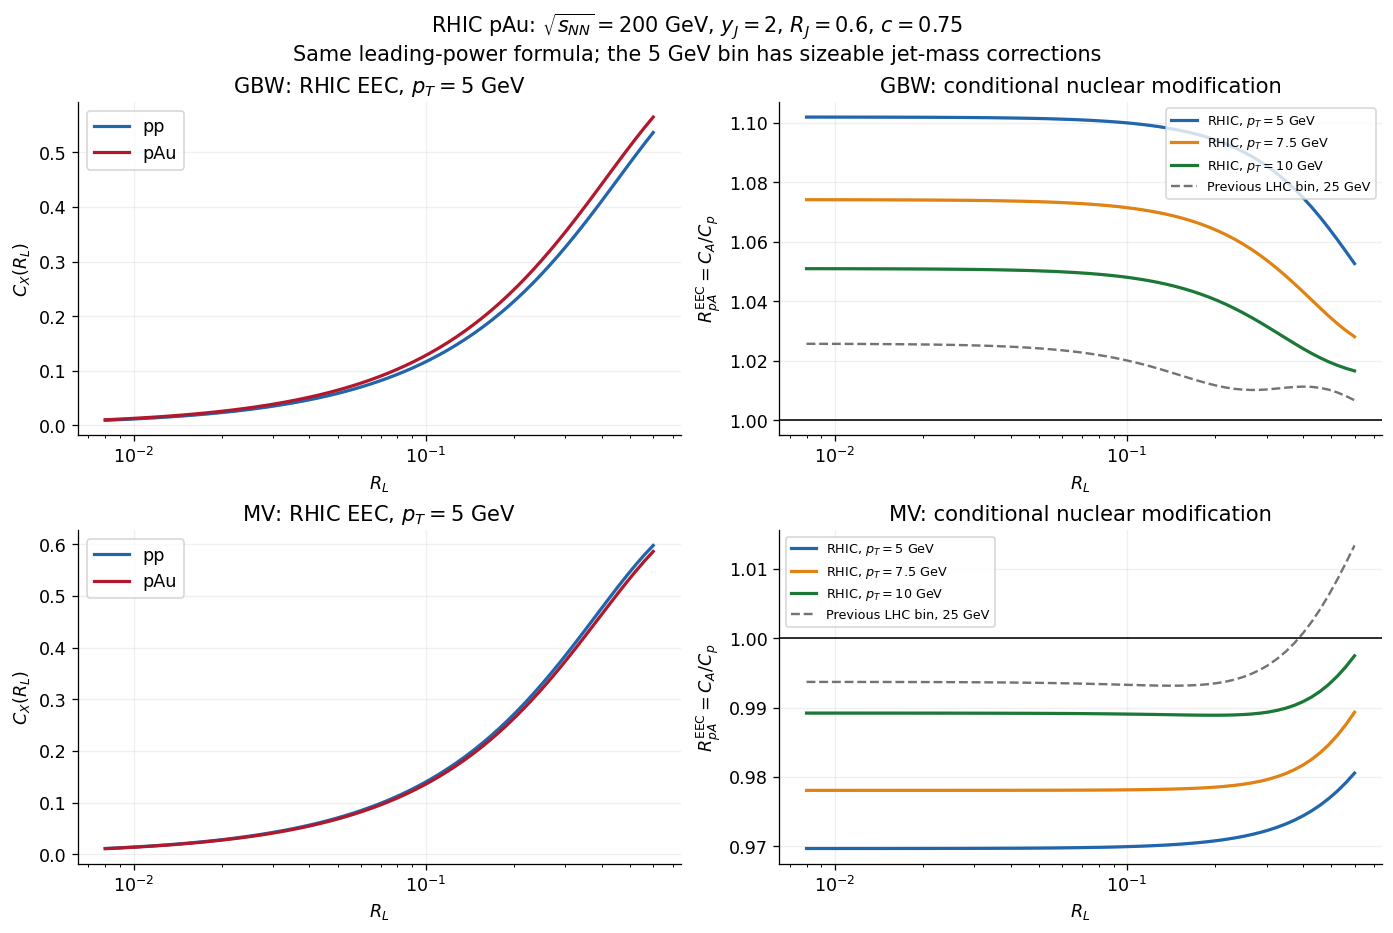

In [7]:
colors = {'RHIC_5':'#2166ac', 'RHIC_7p5':'#e08214', 'RHIC_10':'#1b7837'}
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for i, model in enumerate(['GBW', 'MV']):
    first = results['RHIC_5', model]
    ax, ar = axes[i]
    for target, color, label in [('p','#2166ac','pp'),('A','#b2182b','pAu')]:
        d = first[target]
        ax.plot(R_L, d['C'], color=color, lw=2, label=label)
        ax.fill_between(R_L,d['C']-d['C_error'],d['C']+d['C_error'],color=color,alpha=.2)
    ax.set(xscale='log', xlabel=r'$R_L$', ylabel=r'$C_X(R_L)$',
           title=rf'{model}: RHIC EEC, $p_T=5$ GeV')
    ax.legend()
    for name, color in colors.items():
        r = results[name, model]
        ar.plot(R_L, r['ratio'], color=color, lw=2,
                label=rf'RHIC, $p_T={r["physics"].p_T:g}$ GeV')
        ar.fill_between(R_L,r['ratio']-r['ratio_error'],r['ratio']+r['ratio_error'],
                        color=color,alpha=.2)
    ref = results['LHC_25_original',model]
    ar.plot(R_L,ref['ratio'],ls='--',color='0.45',label='Previous LHC bin, 25 GeV')
    ar.axhline(1,color='black',lw=1)
    ar.set(xscale='log',xlabel=r'$R_L$',ylabel=r'$R_{pA}^{\rm EEC}=C_A/C_p$',
           title=f'{model}: conditional nuclear modification')
    ar.legend(fontsize=8)
fig.suptitle(r'RHIC pAu: $\sqrt{s_{NN}}=200$ GeV, $y_J=2$, $R_J=0.6$, $c=0.75$'
             '\nSame leading-power formula; the 5 GeV bin has sizeable jet-mass corrections',fontsize=13)
fig.savefig(OUTPUT/'rhic_eec_comparison.png')
plt.show()

## Energy controls and what normalization removes

The matched controls use Au at both energies as a theoretical comparison; the 5.02 TeV Au curves
are not a claim about an existing experimental Au run. The original LHC curve above uses Pb.

Decompose the EEC as $C_X(R)=\mathcal P_X(R)\,\overline b_X(R)$, where $\mathcal P_X$ is
the unit-normalized, unweighted pair-angle distribution and $\overline b_X$ is the conditional
mean of $z(1-z)$. A change in the integral of the EEC reflects a change in energy sharing.
A ratio shifted away from one need not be an equally large angular-shape distortion.

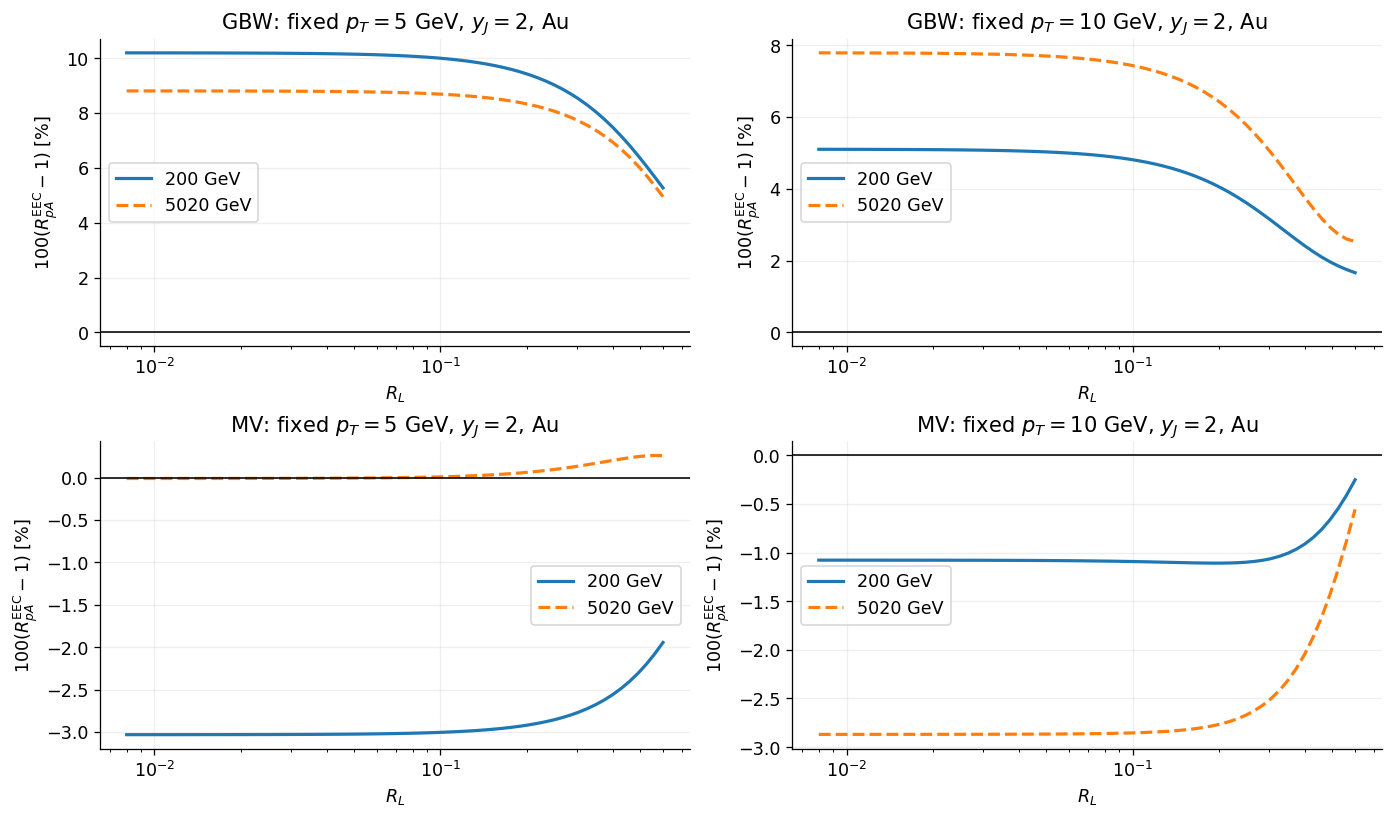

,case,model,R_L,EEC_ratio,angular_probability_ratio,conditional_energy_weight_ratio
0,RHIC_5,GBW,0.1,1.100010,1.022844,1.075443
1,RHIC_5,GBW,0.3,1.085584,1.009798,1.075050
2,RHIC_5,GBW,0.6,1.052698,0.979582,1.074640
3,RHIC_5,MV,0.1,0.969958,0.993418,0.976384
4,RHIC_5,MV,0.3,0.972263,0.996708,0.975474
5,RHIC_5,MV,0.6,0.980566,1.007634,0.973137
6,RHIC_7p5,GBW,0.1,1.071503,1.023202,1.047205
7,RHIC_7p5,GBW,0.3,1.053868,1.007384,1.046143
8,RHIC_7p5,GBW,0.6,1.028106,0.982850,1.046046
9,RHIC_7p5,MV,0.1,0.978154,0.993143,0.984907


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
for row, model in enumerate(['GBW','MV']):
    for col,P in enumerate([5,10]):
        ax = axes[row,col]
        for name,label,style in [(f'RHIC_{P}','200 GeV','-'),
                                  (f'LHC_{P}_matched','5020 GeV','--')]:
            r=results[name,model]
            ax.plot(R_L,100*(r['ratio']-1),ls=style,lw=2,label=label)
            ax.fill_between(R_L,100*(r['ratio']-1-r['ratio_error']),
                             100*(r['ratio']-1+r['ratio_error']),alpha=.15)
        ax.axhline(0,color='black',lw=1)
        ax.set(xscale='log',xlabel=r'$R_L$',ylabel=r'$100(R_{pA}^{\rm EEC}-1)$ [%]',
               title=rf'{model}: fixed $p_T={P}$ GeV, $y_J=2$, Au')
        ax.legend()
fig.savefig(OUTPUT/'matched_energy_controls.png')
plt.show()
decomposition=[]
for name in ['RHIC_5','RHIC_7p5','RHIC_10']:
    for model in ['GBW','MV']:
        r=results[name,model]
        for R in [.1,.3,.6]:
            j=np.argmin(abs(R_L-R))
            decomposition.append(dict(case=name,model=model,R_L=R,
                EEC_ratio=r['ratio'][j],
                angular_probability_ratio=r['A']['probability'][j]/r['p']['probability'][j],
                conditional_energy_weight_ratio=r['A']['conditional_weight'][j]/r['p']['conditional_weight'][j]))
decomposition=pd.DataFrame(decomposition)
display(decomposition)
decomposition.to_csv(OUTPUT/'ratio_decomposition.csv',index=False)

## Mass-approximation diagnostics and independent integration

At a sampled point the pair mass is $M_J^2=(m_Q^2+k^2)/[z(1-z)]$.
The table reports the fraction of the **unweighted pair-jet rate** coming from
$M_J^2/p_T^2>0.25$, together with a direct disk-integral check of the denominator.
This fraction is a diagnostic, not a theoretical error bar. Retaining the exact mass would
also make the PDF and target $x$ depend on internal variables, so they could not be treated
as fixed common prefactors in the same way.

In [9]:
disk_rows=[]
for name in ['RHIC_5','RHIC_7p5','RHIC_10']:
    cfg=CASES[name]
    for model in ['GBW','MV']:
        for target in ['p','A']:
            d=disk_check(model,cfg,NUMERICS,target)
            ref=results[name,model][target]
            discrepancy=d['denominator'].mean()/ref['denominator'].mean()-1
            assert abs(discrepancy)<.003
            assert abs(d['mean_weight'].mean()-ref['mean_weight'].mean())<.001
            assert d['kernel_weight_in_asymptotic_tail']<1e-5
            disk_rows.append(dict(case=name,model=model,target=target,
                disk_denominator_relative_difference=discrepancy,
                fraction_MJ2_over_PT2_gt_025=d['fraction_MJ2_over_PT2_gt_025'],
                fraction_endpoint_z01=d['fraction_endpoint_z01']))
disk_rows=pd.DataFrame(disk_rows)
display(disk_rows)
disk_rows.to_csv(OUTPUT/'mass_and_disk_checks.csv',index=False)

,case,model,target,disk_denominator_relative_difference,fraction_MJ2_over_PT2_gt_025,fraction_endpoint_z01
0,RHIC_5,GBW,p,2.471270e-06,1.000000,0.054193
1,RHIC_5,GBW,A,1.255253e-06,1.000000,0.038918
2,RHIC_5,MV,p,2.710458e-07,1.000000,0.019555
3,RHIC_5,MV,A,2.322632e-05,1.000000,0.026442
4,RHIC_7p5,GBW,p,6.557238e-07,0.172864,0.051333
5,RHIC_7p5,GBW,A,3.934562e-06,0.147341,0.043865
6,RHIC_7p5,MV,p,-2.161628e-05,0.068516,0.018615
7,RHIC_7p5,MV,A,-3.178693e-06,0.085507,0.024686
8,RHIC_10,GBW,p,-2.986714e-06,0.024837,0.050074
9,RHIC_10,GBW,A,5.297292e-06,0.022813,0.045972


## Convergence and exports

At the smallest and largest RHIC jet momenta, double the Sobol point count.
For the 5 GeV MV case also vary the importance proposal and radial quadrature.
The original LHC notebook separately tested the Fourier-grid refinement.

In [10]:
convergence=[]
if RUN_CONVERGENCE:
    idx=np.unique(np.linspace(0,len(R_L)-1,11,dtype=int))
    for name in ['RHIC_5','RHIC_10']:
        for model in ['GBW','MV']:
            fine=solve_pair(model,CASES[name],replace(NUMERICS,power=NUMERICS.power+1),R_L[idx])
            delta=np.max(abs(fine['ratio']-results[name,model]['ratio'][idx]))
            assert delta<.001
            convergence.append(dict(case=name,model=model,check='double Sobol samples',max_abs_ratio_change=delta))
    for label,num,width in [('double radial nodes',replace(NUMERICS,n_R=2*NUMERICS.n_R),1.0),
                             ('proposal width x 1.5',NUMERICS,1.5)]:
        alternate=solve_pair('MV',CASES['RHIC_5'],num,R_L[idx],proposal_scale=width)
        delta=np.max(abs(alternate['ratio']-results['RHIC_5','MV']['ratio'][idx]))
        assert delta<.001
        convergence.append(dict(case='RHIC_5',model='MV',check=label,max_abs_ratio_change=delta))
    convergence=pd.DataFrame(convergence)
    display(convergence)
    convergence.to_csv(OUTPUT/'convergence.csv',index=False)
metadata=dict(cases={name:asdict(cfg) for name,cfg in CASES.items()},numerics=asdict(NUMERICS),
              numpy=np.__version__,scipy=scipy.__version__,
              approximation='same leading-power, massless-jet kinematics as LHC notebook',
              observable='EEC per QQbar-containing jet; nuclear ratio C_A/C_p')
(OUTPUT/'run_metadata.json').write_text(json.dumps(metadata,indent=2))
print('Saved results to',OUTPUT.resolve())

,case,model,check,max_abs_ratio_change
0,RHIC_5,GBW,double Sobol samples,1.577142e-06
1,RHIC_5,MV,double Sobol samples,2.006460e-06
2,RHIC_10,GBW,double Sobol samples,5.637085e-06
3,RHIC_10,MV,double Sobol samples,4.628422e-05
4,RHIC_5,MV,double radial nodes,3.330669e-16
5,RHIC_5,MV,proposal width x 1.5,8.705665e-06


Saved results to /Users/carloslamasrodriguez/Documents/in_jet_eec/rhic_results


## Interpretation limits

Compare the two models before interpreting the magnitude as a saturation signal. GBW's Gaussian
hard-momentum tail remains a limitation even when its common exponential is cancelled exactly.
The classical MV calculation includes neither BK evolution nor a matched dilute reference.
The numerical bands exclude those theory uncertainties and the mass-kinematics approximation.
No experimental significance or absolute pair-jet yield is inferred from this conditional ratio.

References: the user's *In_jet_EECs-11.pdf*, corrected Eqs. (36)–(40);
[GBW](https://arxiv.org/abs/hep-ph/9807513);
[MV-type parametrization and forward RHIC/LHC context](https://arxiv.org/abs/1309.6963).
The latter supplies context, not the numerical EEC predictions shown here.